<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/Apriori_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Dataset loaded successfully!
                                                name  \
0  Birds Eye Crispy Pancakes Beef & Onion 4 Pack ...   
1                   Unicorn & Dino Storybooks 4 Pack   
2                        Schwartz Fish Seasoning 55G   
3                 Hearty Food Co Mac 'N' Cheese 400G   
4                           Tesco Dijon Mustard 185G   

                                                 url        sku  \
0  https://www.tesco.com/groceries/en-GB/products...  305829059   
1  https://www.tesco.com/groceries/en-GB/products...  311932942   
2  https://www.tesco.com/groceries/en-GB/products...  257522449   
3  https://www.tesco.com/groceries/en-GB/products...  299555755   
4  https://www.tesco.com/groceries/en-GB/products...  260691710   

          gtin13  price currency availability  \
0  5000116125234   2.20      GBP   OutOfStock   
1  9781803683058   1.50      GBP      InStock   
2       50020881   1.85      GBP      InStock   
3  5057545678336   0.75      GBP   

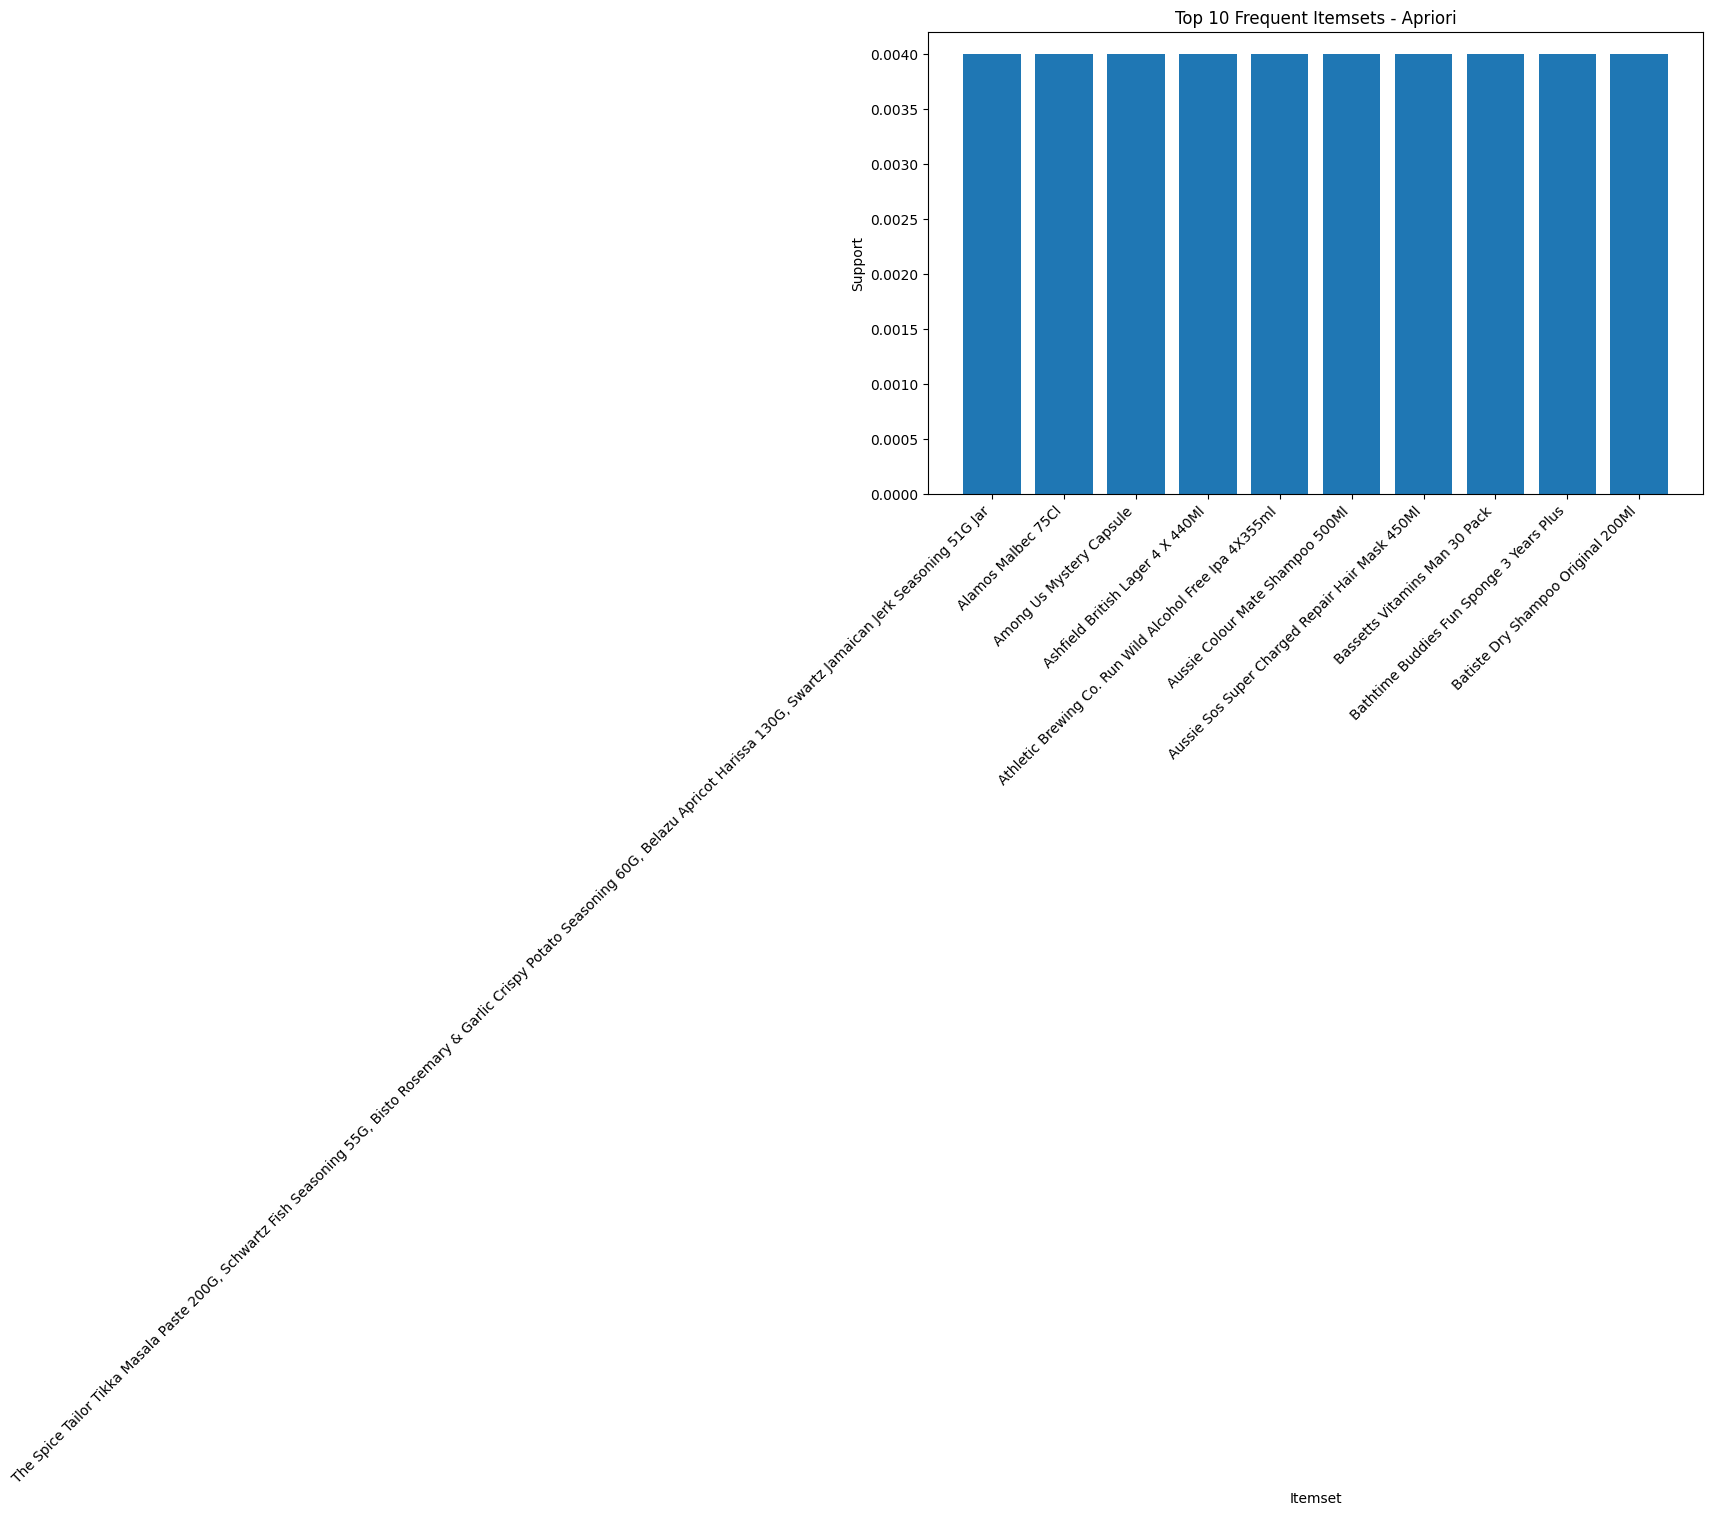

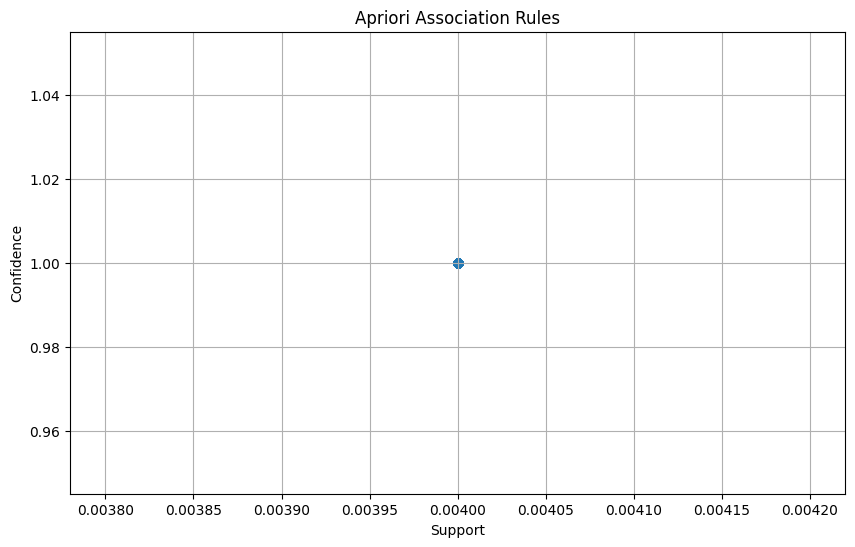

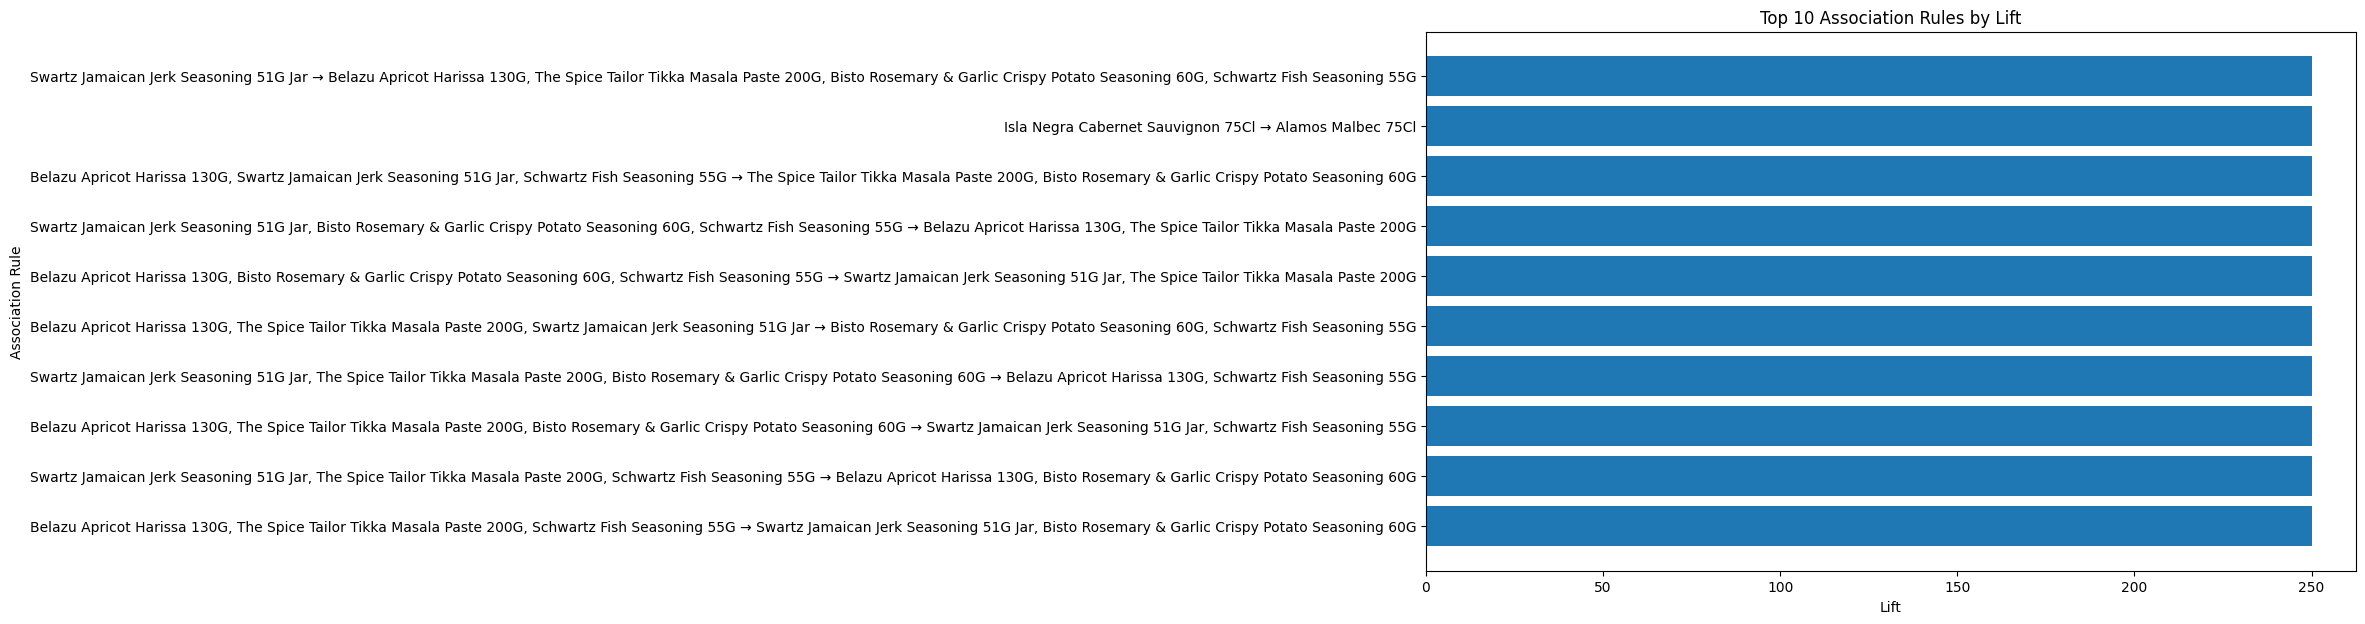

In [6]:
import warnings
warnings.filterwarnings("ignore")


import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules


# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("/content/tesco_groceries_dataset-selected-columns.csv")

print("Dataset loaded successfully!")
print(df.head())

print("\nColumns:")
print(df.columns)


# ============================================
# 2. CREATE TRANSACTIONS
# ============================================

# The original intention was to use Member_number, Date, and itemDescription.
# Given the available columns ('name', 'url', 'sku', 'gtin13', 'price', 'currency', 'availability',
# 'description', 'brand', 'breadcrumbs'), we will adapt the transaction definition.
# We will consider each unique 'breadcrumbs' entry as a 'transaction',
# and the 'name' of the products within that category as the 'items' in that transaction.
# This helps find associations between products within the same categories.

transactions = (
    df.groupby(
        ["breadcrumbs"]
    )["name"]
    .apply(list)
    .values
)

print("\nNumber of transactions:",
      len(transactions))


# ============================================
# 3. TRANSACTION ENCODING
# ============================================

encoder = TransactionEncoder()

encoded_data = encoder.fit(
    transactions
).transform(transactions)

basket = pd.DataFrame(
    encoded_data,
    columns=encoder.columns_
)

print("\nEncoded Dataset:")
print(basket.head())


# ============================================
# 4. APRIORI ALGORITHM
# ============================================

frequent_itemsets = apriori(
    basket,
    min_support=0.001, # Lowered min_support to find more frequent itemsets
    use_colnames=True
)


# ============================================
# 5. DISPLAY FREQUENT ITEMSETS
# ============================================

print("\nFrequent Itemsets:")

print(
    frequent_itemsets.sort_values(
        by="support",
        ascending=False
    ).head(20)
)


# ============================================
# 6. ASSOCIATION RULES
# ============================================

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.2
)


# ============================================
# 7. DISPLAY RULES
# ============================================

print("\nAssociation Rules:")

print(
    rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].sort_values(
        by="lift",
        ascending=False
    ).head(20)
)


# ============================================
# 8. TOP 10 FREQUENT ITEMS
# ============================================

item_support = frequent_itemsets.copy()

item_support["item"] = (
    item_support["itemsets"]
    .apply(lambda x: ", ".join(x))
)

top_items = item_support.sort_values(
    by="support",
    ascending=False
).head(10)


# ============================================
# 9. GRAPH 1 - FREQUENT ITEMSETS
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    top_items["item"],
    top_items["support"]
)

plt.xlabel("Itemset")
plt.ylabel("Support")

plt.title(
    "Top 10 Frequent Itemsets - Apriori"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================
# 10. GRAPH 2 - CONFIDENCE VS SUPPORT
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    rules["support"],
    rules["confidence"]
)

plt.xlabel("Support")
plt.ylabel("Confidence")

plt.title(
    "Apriori Association Rules"
)

plt.grid(True)

plt.show()


# ============================================
# 11. GRAPH 3 - TOP ASSOCIATION RULES
# ============================================

top_rules = rules.sort_values(
    by="lift",
    ascending=False
).head(10)

rule_names = []

for _, row in top_rules.iterrows():

    antecedent = ", ".join(
        row["antecedents"]
    )

    consequent = ", ".join(
        row["consequents"]
    )

    rule_names.append(
        antecedent +
        " → " +
        consequent
    )


plt.figure(figsize=(12, 7))

plt.barh(
    rule_names,
    top_rules["lift"]
)

plt.xlabel("Lift")

plt.ylabel("Association Rule")

plt.title(
    "Top 10 Association Rules by Lift"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()